### A **GRU-based version** for comparison. GRU (Gated Recurrent Unit) networks are similar to LSTMs but have fewer parameters and can train faster while often performing comparably.


In [1]:
import os
import numpy as np
import pandas as pd
from sklearn.utils import class_weight
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import tensorflow as tf

In [2]:
# ----- Define Focal Loss Function -----
def focal_loss(gamma=2., alpha=0.25):
    def focal_loss_fixed(y_true, y_pred):
        epsilon = tf.keras.backend.epsilon()
        y_pred = tf.clip_by_value(y_pred, epsilon, 1. - epsilon)
        cross_entropy = -y_true * tf.math.log(y_pred)
        weight = alpha * tf.pow(1 - y_pred, gamma)
        loss = weight * cross_entropy
        return tf.reduce_sum(loss, axis=1)
    return focal_loss_fixed

In [24]:
label_map = {'Bitumin': 0, 'Block': 1, 'Concrete': 2, 'Kanker': 3}
# ----- Load Your Dataset -----
def load_all_sequences(base_path,CS):
    X, y = [], []
    label_map = {'Bitumin': 0, 'Block': 1, 'Concrete': 2, 'Kanker': 3}
    for label_name, label in label_map.items():
        folder = os.path.join(base_path, label_name)
        for file in os.listdir(folder):
            if file.endswith(".csv"):
                data = pd.read_csv(os.path.join(folder, file))
                if len(data) == CS:
                    values = data[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values
                    X.append(values)
                    y.append(label)
    return np.array(X), np.array(y)

# Harshit_Preprocessed_Data-CS200U

In [25]:
# Define base directory
base_dir = "Dataset/Harshit_Preprocessed_Data-CS200"

X, y = load_all_sequences(base_dir,CS=200)
print(X.shape, y.shape)

(1403, 200, 6) (1403,)


In [5]:
# ----- Normalize -----
scaler = StandardScaler()
X_scaled = np.array([scaler.fit_transform(x) for x in X])

# ----- Encode Labels -----
y_cat = to_categorical(y, num_classes=4)

# ----- Split -----
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y)

# ----- Compute Class Weights -----
y_int = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

In [6]:
# ----- Build GRU Model -----
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru (GRU)                       │ (None, 200, 64)        │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 200, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_1 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,420 (95.39 KB)

 Trainable params: 24,420 (95.39 KB)

 Non-trainable params: 0 (0.00 B)

In [7]:
# ----- Train -----
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 6s 96ms/step - accuracy: 0.2464 - loss: 0.1985 - val_accuracy: 0.2954 - val_loss: 0.1932
Epoch 2/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 91ms/step - accuracy: 0.2518 - loss: 0.1969 - val_accuracy: 0.2989 - val_loss: 0.1912
Epoch 3/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 84ms/step - accuracy: 0.2964 - loss: 0.1923 - val_accuracy: 0.2847 - val_loss: 0.1930
Epoch 4/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.2903 - loss: 0.1874 - val_accuracy: 0.3060 - val_loss: 0.1914
Epoch 5/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 4s 110ms/step - accuracy: 0.3244 - loss: 0.1886 - val_accuracy: 0.3274 - val_loss: 0.1908
Epoch 6/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 95ms/step - accuracy: 0.3616 - loss: 0.1861 - val_accuracy: 0.3843 - val_loss: 0.1819
Epoch 7/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 90ms/step - accuracy: 0.4096 - loss: 0.1793 - val_accuracy: 0.4128 - val_loss: 0.1718
Epoch 8/20
36/36 ━━━━━━━━━━━━━━━━━━━━ 3s 92ms/step - accuracy: 0.3765 - loss: 0.1713 - val_accuracy: 0.4306 - 

## Step 5: Evaluate and Visualize Performance

In [20]:
import matplotlib.pyplot as plt

def PlotCurves(history):
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # ----- Plot Loss -----
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

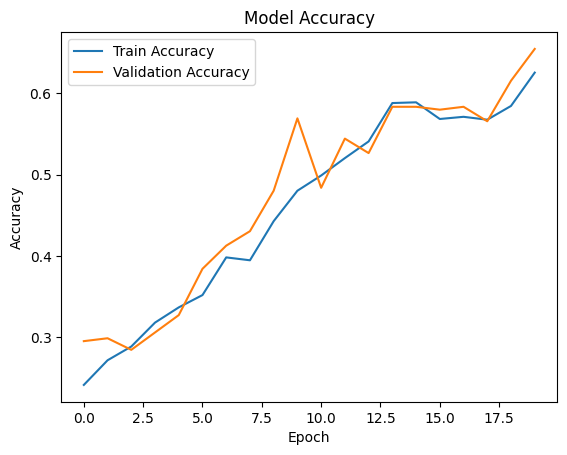

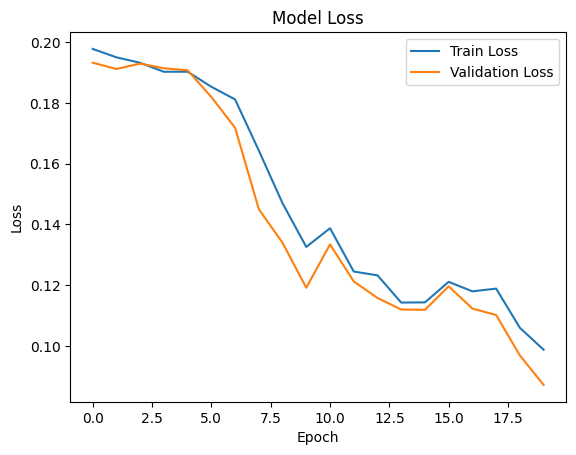

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.6927 - loss: 0.0809
Test Accuracy: 0.65


In [21]:
PlotCurves(history)
# Evaluate
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Test Accuracy: {accuracy:.2f}")

## Confusion Matrix

44/44 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step
              precision    recall  f1-score   support

     Bitumin       0.38      0.98      0.55       504
       Block       0.44      0.04      0.07       374
    Concrete       0.47      0.09      0.16       274
      Kanker       0.81      0.07      0.12       251

    accuracy                           0.39      1403
   macro avg       0.52      0.29      0.22      1403
weighted avg       0.49      0.39      0.27      1403



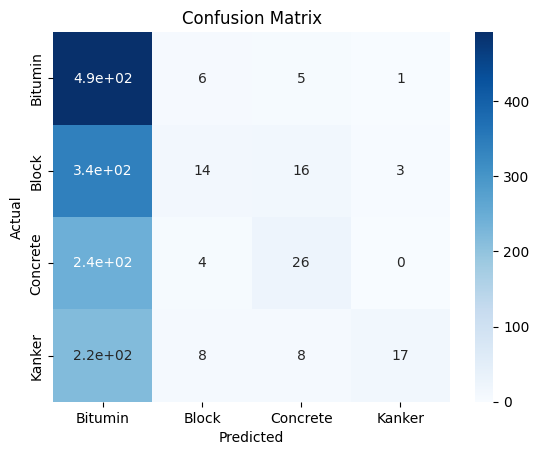

In [9]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = np.argmax(model.predict(X), axis=1)

# Evaluation
print(classification_report(y, y_pred, target_names=label_map.keys()))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save the Trained Model

In [11]:
# ----- Save Model -----
model.save('Models/Model_Architecture(CS200-U)GRU.h5')

###  load the GRU model for testing

In [13]:
model = tf.keras.models.load_model('Models/Model_Architecture(CS200-U)GRU.h5', custom_objects={'focal_loss_fixed': focal_loss()})

#### Step 3: Load and Prepare Real-Time or Test Data

In [14]:
# Example: Path to one of your 200-row test CSVs
test_file_path = "Dataset/Harshit_Preprocessed_Data-CS200/Bitumin/001_Abj_Bitumin_1_12-2_part_001.csv"  # replace with your actual path

# Load CSV
df_test = pd.read_csv(test_file_path)

# Extract only numeric columns (assumes sensor data are only numeric)
X_test = df_test[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values

# Standardize using same scaler used during training (Assuming fit on full training set)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Reshape for LSTM [samples, time_steps, features]
X_test_scaled = X_test_scaled.reshape(1, X_test_scaled.shape[0], X_test_scaled.shape[1])


#### Step 4: Make Prediction

In [15]:
# Make prediction
pred_probs = model.predict(X_test_scaled)
pred_class = np.argmax(pred_probs)

# Mapping label index to actual class names
label_map = {0: 'Bitumin', 1: 'Block', 2: 'Concrete', 3: 'Kankar'}
print("Predicted Road Type:", label_map[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 240ms/step
Predicted Road Type: Bitumin


---

---

# Harshit_Preprocessed_Data-CS250U

In [30]:
# Define base directory
base_dir = "Dataset/Harshit_Preprocessed_Data-CS250"

X, y = load_all_sequences(base_dir,CS=250)
print(X.shape, y.shape)

(1114, 250, 6) (1114,)


In [31]:
# ----- Normalize -----
scaler = StandardScaler()
X_scaled = np.array([scaler.fit_transform(x) for x in X])

# ----- Encode Labels -----
y_cat = to_categorical(y, num_classes=4)

# ----- Split -----
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y)

# ----- Compute Class Weights -----
y_int = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

In [32]:
# ----- Build GRU Model -----
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_4 (GRU)                     │ (None, 250, 64)        │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 250, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_5 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,420 (95.39 KB)

 Trainable params: 24,420 (95.39 KB)

 Non-trainable params: 0 (0.00 B)

In [33]:
# ----- Train -----
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/20


28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 148ms/step - accuracy: 0.2327 - loss: 0.1969 - val_accuracy: 0.2735 - val_loss: 0.1936
Epoch 2/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.2843 - loss: 0.1958 - val_accuracy: 0.3498 - val_loss: 0.1918
Epoch 3/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.3220 - loss: 0.1903 - val_accuracy: 0.3318 - val_loss: 0.1902
Epoch 4/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 129ms/step - accuracy: 0.3024 - loss: 0.1923 - val_accuracy: 0.3408 - val_loss: 0.1906
Epoch 5/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step - accuracy: 0.3059 - loss: 0.1910 - val_accuracy: 0.3318 - val_loss: 0.1894
Epoch 6/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 131ms/step - accuracy: 0.3611 - loss: 0.1829 - val_accuracy: 0.3408 - val_loss: 0.1874
Epoch 7/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 136ms/step - accuracy: 0.3724 - loss: 0.1797 - val_accuracy: 0.3498 - val_loss: 0.1876
Epoch 8/20
28/28 ━━━━━━━━━━━━━━━━━━━━ 4s 155ms/step - accuracy: 0.4084 - loss: 0.1751 - val_accuracy: 0.3274 - val_

## Step 5: Evaluate and Visualize Performance

In [34]:
import matplotlib.pyplot as plt

def PlotCurves(history):
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # ----- Plot Loss -----
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

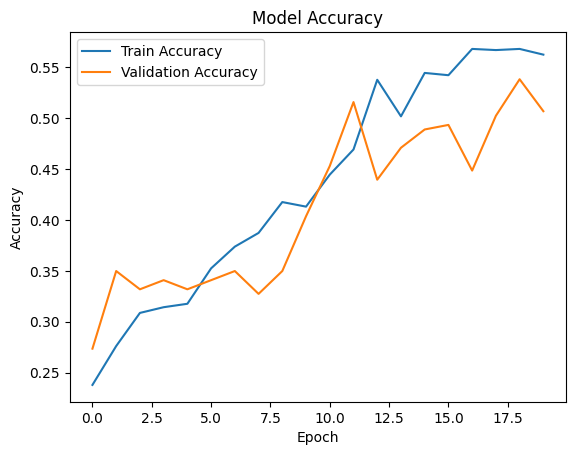

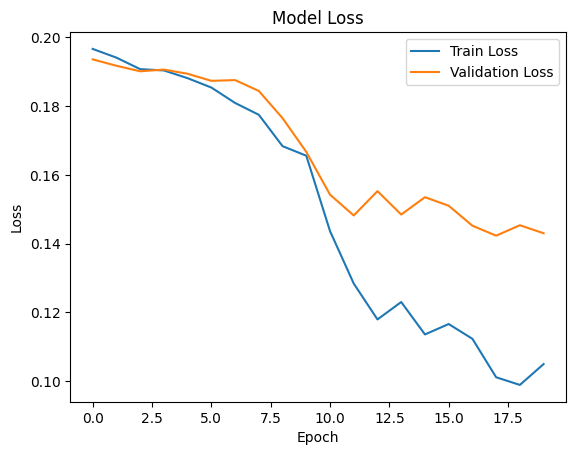

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5046 - loss: 0.1580
Test Accuracy: 0.51


In [35]:
PlotCurves(history)
# Evaluate
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Test Accuracy: {accuracy:.2f}")

## Confusion Matrix

35/35 ━━━━━━━━━━━━━━━━━━━━ 2s 37ms/step
              precision    recall  f1-score   support

     Bitumin       0.39      0.88      0.54       399
       Block       0.29      0.01      0.01       297
    Concrete       0.53      0.15      0.24       220
      Kanker       0.26      0.19      0.22       198

    accuracy                           0.38      1114
   macro avg       0.37      0.31      0.25      1114
weighted avg       0.37      0.38      0.28      1114



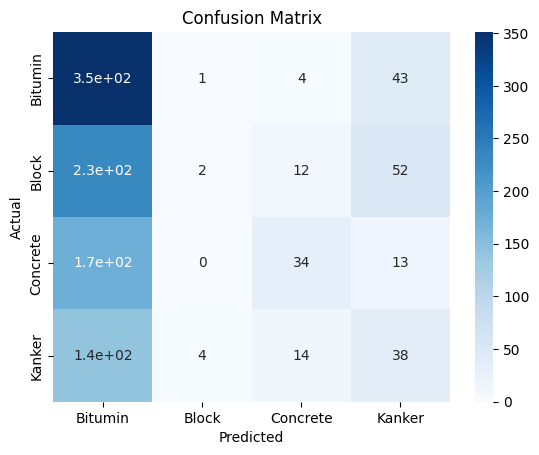

In [36]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = np.argmax(model.predict(X), axis=1)

# Evaluation
print(classification_report(y, y_pred, target_names=label_map.keys()))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save the Trained Model

In [37]:
# ----- Save Model -----
model.save('Models/Model_Architecture(CS250-U)GRU.h5')

###  load the GRU model for testing

In [38]:
model = tf.keras.models.load_model('Models/Model_Architecture(CS250-U)GRU.h5', custom_objects={'focal_loss_fixed': focal_loss()})

#### Step 3: Load and Prepare Real-Time or Test Data

In [39]:
# Example: Path to one of your 200-row test CSVs
test_file_path = "Dataset/Harshit_Preprocessed_Data-CS250/Bitumin/001_Abj_Bitumin_1_12-2_part_001.csv"  # replace with your actual path

# Load CSV
df_test = pd.read_csv(test_file_path)

# Extract only numeric columns (assumes sensor data are only numeric)
X_test = df_test[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values

# Standardize using same scaler used during training (Assuming fit on full training set)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Reshape for LSTM [samples, time_steps, features]
X_test_scaled = X_test_scaled.reshape(1, X_test_scaled.shape[0], X_test_scaled.shape[1])


#### Step 4: Make Prediction

In [40]:
# Make prediction
pred_probs = model.predict(X_test_scaled)
pred_class = np.argmax(pred_probs)

# Mapping label index to actual class names
label_map = {0: 'Bitumin', 1: 'Block', 2: 'Concrete', 3: 'Kankar'}
print("Predicted Road Type:", label_map[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step
Predicted Road Type: Kankar


---
---

# Harshit_Preprocessed_Data-CS300U

In [42]:
# Define base directory
base_dir = "Dataset/Harshit_Preprocessed_Data-CS300"

X, y = load_all_sequences(base_dir,CS=300)
print(X.shape, y.shape)

(922, 300, 6) (922,)


In [43]:
# ----- Normalize -----
scaler = StandardScaler()
X_scaled = np.array([scaler.fit_transform(x) for x in X])

# ----- Encode Labels -----
y_cat = to_categorical(y, num_classes=4)

# ----- Split -----
X_train, X_val, y_train, y_val = train_test_split(X_scaled, y_cat, test_size=0.2, random_state=42, stratify=y)

# ----- Compute Class Weights -----
y_int = np.argmax(y_train, axis=1)
class_weights = class_weight.compute_class_weight(class_weight='balanced', classes=np.unique(y_int), y=y_int)
class_weight_dict = dict(enumerate(class_weights))

In [44]:
# ----- Build GRU Model -----
model = Sequential([
    GRU(64, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])),
    Dropout(0.3),
    GRU(32),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(4, activation='softmax')
])

model.compile(optimizer='adam', loss=focal_loss(), metrics=['accuracy'])
model.summary()

c:\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ gru_6 (GRU)                     │ (None, 300, 64)        │        13,824 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 300, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru_7 (GRU)                     │ (None, 32)             │         9,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 4)              │           132 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,420 (95.39 KB)

 Trainable params: 24,420 (95.39 KB)

 Non-trainable params: 0 (0.00 B)

In [45]:
# ----- Train -----
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict
)

Epoch 1/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 7s 155ms/step - accuracy: 0.1983 - loss: 0.2003 - val_accuracy: 0.2811 - val_loss: 0.1954
Epoch 2/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 157ms/step - accuracy: 0.2682 - loss: 0.1948 - val_accuracy: 0.2486 - val_loss: 0.1956
Epoch 3/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.2941 - loss: 0.1913 - val_accuracy: 0.2649 - val_loss: 0.1930
Epoch 4/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 160ms/step - accuracy: 0.3129 - loss: 0.1901 - val_accuracy: 0.3027 - val_loss: 0.1903
Epoch 5/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 184ms/step - accuracy: 0.3538 - loss: 0.1824 - val_accuracy: 0.3459 - val_loss: 0.1878
Epoch 6/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 146ms/step - accuracy: 0.3141 - loss: 0.1872 - val_accuracy: 0.3405 - val_loss: 0.1870
Epoch 7/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 4s 158ms/step - accuracy: 0.3608 - loss: 0.1779 - val_accuracy: 0.3676 - val_loss: 0.1817
Epoch 8/20
24/24 ━━━━━━━━━━━━━━━━━━━━ 3s 142ms/step - accuracy: 0.3982 - loss: 0.1795 - val_accuracy: 0.

## Step 5: Evaluate and Visualize Performance

In [49]:
import matplotlib.pyplot as plt

def PlotCurves(history):
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    # ----- Plot Loss -----
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

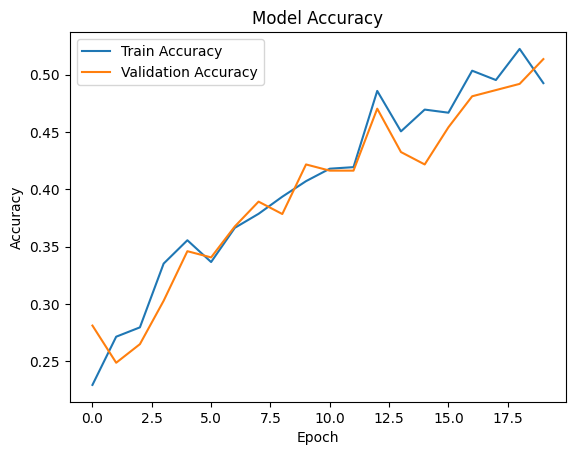

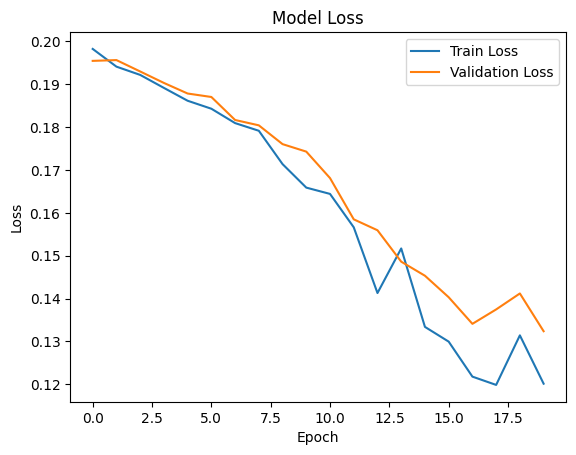

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - accuracy: 0.5431 - loss: 0.1253
Test Accuracy: 0.51


In [50]:
PlotCurves(history)
# Evaluate
loss, accuracy = model.evaluate(X_val, y_val)
print(f"Test Accuracy: {accuracy:.2f}")

## Confusion Matrix

29/29 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step


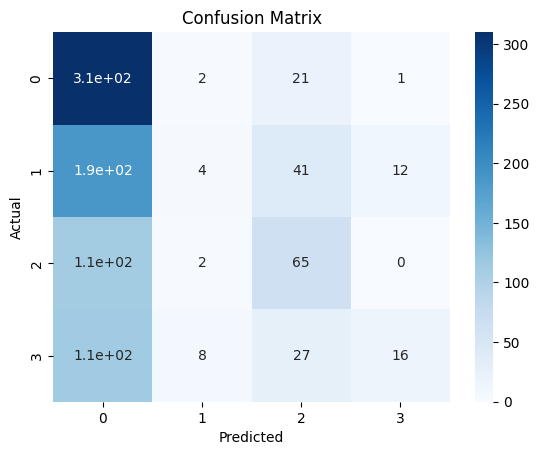

In [52]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict
y_pred = np.argmax(model.predict(X), axis=1)

# Evaluation
# print(classification_report(y, y_pred, target_names=label_map.keys()))

# Confusion Matrix
cm = confusion_matrix(y, y_pred)
sns.heatmap(cm, annot=True, cmap='Blues', xticklabels=label_map.keys(), yticklabels=label_map.keys())
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

## Save the Trained Model

In [53]:
# ----- Save Model -----
model.save('Models/Model_Architecture(CS300-U)GRU.h5')

###  load the GRU model for testing

In [54]:
model = tf.keras.models.load_model('Models/Model_Architecture(CS300-U)GRU.h5', custom_objects={'focal_loss_fixed': focal_loss()})

#### Step 3: Load and Prepare Real-Time or Test Data

In [55]:
# Example: Path to one of your 200-row test CSVs
test_file_path = "Dataset/Harshit_Preprocessed_Data-CS300/Bitumin/001_Abj_Bitumin_1_12-2_part_001.csv"  # replace with your actual path

# Load CSV
df_test = pd.read_csv(test_file_path)

# Extract only numeric columns (assumes sensor data are only numeric)
X_test = df_test[['X_Acc', 'Y_Acc', 'Z_Acc', 'X_Gyro', 'Y_Gyro', 'Z_Gyro']].values

# Standardize using same scaler used during training (Assuming fit on full training set)
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)

# Reshape for LSTM [samples, time_steps, features]
X_test_scaled = X_test_scaled.reshape(1, X_test_scaled.shape[0], X_test_scaled.shape[1])


#### Step 4: Make Prediction

In [56]:
# Make prediction
pred_probs = model.predict(X_test_scaled)
pred_class = np.argmax(pred_probs)

# Mapping label index to actual class names
label_map = {0: 'Bitumin', 1: 'Block', 2: 'Concrete', 3: 'Kankar'}
print("Predicted Road Type:", label_map[pred_class])


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step
Predicted Road Type: Kankar
